# Сравнение различных подходов к Voice Activity Detection (VAD)
В этом ноутбуке мы реализуем и сравним 4 подхода к детектированию речи на датасете RAVDESS:
1. **MLP** (Многослойный перцептрон) на признаках MFCC
2. **LSTM** (Рекуррентная сеть) для учета временного контекста
3. **1D-CNN** (Сверточная сеть) для извлечения паттернов из аудио
4. **MediaPipe** (Визуальный VAD) на основе расстояния между губами

In [2]:
import os
import cv2
import librosa
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import gc
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
# 1. Загрузка Wav2Vec2 (SOTA экстрактор признаков)
w2v_model_name = "facebook/wav2vec2-base-960h"
w2v_extractor = Wav2Vec2FeatureExtractor.from_pretrained(w2v_model_name)
w2v_model = Wav2Vec2Model.from_pretrained(w2v_model_name).to(device)
w2v_model.eval() # Только извлечение признаков

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wav2Vec2Model(
  (feature_extractor): Wav2Vec2FeatureEncoder(
    (conv_layers): ModuleList(
      (0): Wav2Vec2GroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): Wav2Vec2FeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Wav2Vec2Encoder(
    (pos_conv_embed): Wav2Vec2PositionalConvEmbedding(
  

## 1. Подготовка данных RAVDESS

In [4]:
RAVDESS_PATH = "../datasets/orvile/ravdess-dataset/versions/1/"
MODEL_ASSET_PATH = "../raw_models/face_landmarker.task"

def get_paired_files(path, limit=100):
    """Находит пары аудио-видео файлов RAVDESS"""
    pairs = []
    # Ищем в Audio_Speech
    audio_base = os.path.join(path, "Audio_Speech_Actors_01-24")
    for actor_dir in sorted(os.listdir(audio_base)):
        if not actor_dir.startswith("Actor_"): continue
        audio_path = os.path.join(audio_base, actor_dir)
        for file in os.listdir(audio_path):
            if file.endswith(".wav"):
                video_name = "01" + file[2:-4] + ".mp4"
                video_folder = "Video_Speech_" + actor_dir
                video_path = os.path.join(path, video_folder, actor_dir, video_name)
                
                if os.path.exists(video_path):
                    pairs.append({"audio": os.path.join(audio_path, file), "video": video_path})
                
                if len(pairs) >= limit: return pairs
    return pairs

paired_data = get_paired_files(RAVDESS_PATH, limit=1000000)
print(f"Найдено {len(paired_data)} пар аудио-видео.")

Найдено 1440 пар аудио-видео.


## 2. Извлечение признаков

In [5]:
def get_emotion_label_from_file(file_path):
    """0 - Neutral/Calm, 1 - Emotional"""
    parts = os.path.basename(file_path).split('-')
    emotion_code = int(parts[2])
    return 0 if emotion_code <= 2 else 1

def extract_audio_features(file_path, n_mfcc=40):
    y, sr = librosa.load(file_path, sr=16000)
    
    # 1. Признаки (MFCC)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=320)
    num_frames = mfcc.shape[1]
    
    # 2. Простейший VAD через RMS (энергию)
    rms = librosa.feature.rms(y=y, hop_length=320)[0]
    # Порог: 10% от максимальной энергии файла
    speech_mask = rms > (np.max(rms) * 0.1)
    
    # 3. Эмоция из файла
    is_emotional = get_emotion_label_from_file(file_path)
    
    # 4. Wav2Vec2 признаки (по кадрам)
    inputs = w2v_extractor(y, return_tensors="pt", sampling_rate=16000).to(device)
    with torch.no_grad():
        # last_hidden_state: (1, seq_len, 768) -> (seq_len, 768)
        w2v_feats = w2v_model(**inputs).last_hidden_state.squeeze(0).cpu().numpy()
    
    # 5. Формируем 3 класса:
    # 0 - Silence (RMS < порога)
    # 1 - Neutral Speech (RMS > порога И файл Neutral/Calm)
    # 2 - Emotional Speech (RMS > порога И файл Emotional)
    labels = np.zeros(num_frames, dtype=int)
    # Убеждаемся, что mask не длиннее чем labels
    mask_len = min(len(speech_mask), len(labels))
    labels[:mask_len][speech_mask[:mask_len]] = 1 if is_emotional == 0 else 2
    
    # Синхронизируем длину всех признаков
    min_len = min(num_frames, labels.shape[0], w2v_feats.shape[0])
    return mfcc[:, :min_len].T, labels[:min_len], w2v_feats[:min_len]

X_files = [] # Список признаков MFCC по файлам
X_w2v_files = [] # Список признаков Wav2Vec2 по файлам
y_files = [] # Список меток по файлам
actor_ids = [] # Список ID актеров для каждого файла

print("Извлечение аудио признаков (3 класса: Silence, Neutral, Emotional)...")
for pair in tqdm(paired_data):
    # Извлекаем ID актера из пути (например, из 'Actor_01' достаем 1)
    actor_name = os.path.basename(os.path.dirname(pair['audio']))
    a_id = int(actor_name.split('_')[1])
    
    feats, labs, w2v = extract_audio_features(pair['audio'])
    
    X_files.append(feats)
    X_w2v_files.append(w2v)
    y_files.append(labs)
    actor_ids.append(a_id)

print(f"Обработано {len(X_files)} файлов от {len(set(actor_ids))} актеров.")

Извлечение аудио признаков (3 класса: Silence, Neutral, Emotional)...


100%|██████████| 1440/1440 [01:11<00:00, 20.08it/s]

Обработано 1440 файлов от 24 актеров.


## 3. Определения моделей

In [6]:
class MLP_VAD(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 3) # 3 класса: Silence, Neutral, Emotional
        )
    def forward(self, x): return self.net(x)

class LSTM_VAD(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 32, batch_first=True, num_layers=1)
        self.fc = nn.Linear(32, 3)
    def forward(self, x):
        # x: [batch, seq, feat]
        out, _ = self.lstm(x)
        return self.fc(out)

class CNN1D_VAD(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(input_dim, 32, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(32, 16, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(16, 3, kernel_size=1)
        )
    def forward(self, x):
        # x: (Batch, 1, feat) -> (Batch, feat, 1)
        x = x.transpose(1, 2).contiguous()
        out = self.net(x)
        # out: (Batch, 3, 1) -> (Batch, 1, 3)
        return out.transpose(1, 2).contiguous()

class Wav2Vec_Classifier(nn.Module):
    def __init__(self, input_dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )
    def forward(self, x):
        return self.net(x)

## 4. Обучение аудио моделей

In [7]:
class VADDataset(Dataset):
    def __init__(self, X, y, is_seq=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long) # Для CrossEntropyLoss
        self.is_seq = is_seq

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        if self.is_seq:
            x = x.unsqueeze(0) # (1, feat)
            y = y.unsqueeze(0) # (1,)
        return x, y

In [8]:
def train_model(model, X, y, epochs=15, batch_size=64, is_seq=False):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    dataset = VADDataset(X, y, is_seq=is_seq)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    history = {'loss': [], 'accuracy': []}
    start_time = time.time()
    
    print(f"--- Обучение модели {model.__class__.__name__} ---")
    
    try:
        for epoch in range(epochs):
            model.train()
            epoch_loss = 0
            correct = 0
            total = 0
            
            pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
            
            for batch_X, batch_y in pbar:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                
                optimizer.zero_grad()
                outputs = model(batch_X)
                
                # Приводим к виду (N, 3) и (N) для CrossEntropy
                loss = criterion(outputs.view(-1, 3), batch_y.view(-1))
                loss.backward()
                optimizer.step()
                
                epoch_loss += loss.item()
                
                preds = outputs.argmax(dim=-1)
                correct += (preds == batch_y).sum().item()
                total += batch_y.numel()
                
                pbar.set_postfix({'loss': f"{loss.item():.4f}"})
                
            avg_loss = epoch_loss / len(loader)
            avg_acc = correct / total
            history['loss'].append(avg_loss)
            history['accuracy'].append(avg_acc)
            
            if epoch % 5 == 0:
                print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Acc: {avg_acc:.4f}")
    
    finally:
        # Переносим модель на CPU и очищаем кэш MPS
        model.to('cpu')
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()
        gc.collect()
            
    end_time = time.time()
    print(f"Обучение завершено за {end_time - start_time:.2f} сек.\n")
    return model, history

In [9]:
# 1. Смотрим, какие актеры реально попали в выборку
unique_actors = sorted(list(set(actor_ids)))
print(f"Всего актеров в выборке: {len(unique_actors)} ({unique_actors})")

# 2. Берем последних 20% актеров для теста (но не меньше одного)
n_test = max(1, int(len(unique_actors) * 0.2))
test_actors = unique_actors[-n_test:]

X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []
X_w2v_train_list, X_w2v_test_list = [], []

for i in range(len(X_files)):
    if actor_ids[i] in test_actors:
        X_test_list.append(X_files[i])
        y_test_list.append(y_files[i])
        X_w2v_test_list.append(X_w2v_files[i])
    else:
        X_train_list.append(X_files[i])
        y_train_list.append(y_files[i])
        X_w2v_train_list.append(X_w2v_files[i])

# 3. Теперь vstack не упадет (все признаки по кадрам)
X_train = np.vstack(X_train_list)
y_train = np.concatenate(y_train_list)
X_test = np.vstack(X_test_list)
y_test = np.concatenate(y_test_list)

X_w2v_train = np.vstack(X_w2v_train_list)
X_w2v_test = np.vstack(X_w2v_test_list)

print(f"--- Speaker-Independent Split ---")
print(f"Train actors: {sorted(list(set(actor_ids) - set(test_actors)))}")
print(f"Test actors:  {test_actors}")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"X_w2v_train shape: {X_w2v_train.shape}, X_w2v_test shape: {X_w2v_test.shape}")

Всего актеров в выборке: 24 ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])
--- Speaker-Independent Split ---
Train actors: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Test actors:  [21, 22, 23, 24]
X_train shape: (219787, 40), X_test shape: (45436, 40)
X_w2v_train shape: (219787, 768), X_w2v_test shape: (45436, 768)


In [11]:
print("\nОбучение MLP...")
mlp, mlp_hist = train_model(MLP_VAD(40), X_train, y_train)

print("Обучение LSTM...")
lstm, lstm_hist = train_model(LSTM_VAD(40), X_train, y_train, is_seq=True)

print("Обучение CNN...")
cnn, cnn_hist = train_model(CNN1D_VAD(40), X_train, y_train, is_seq=True)

print("Обучение Wav2Vec Classifier...")
w2v_cls, w2v_hist = train_model(Wav2Vec_Classifier(768), X_w2v_train, y_train)


Обучение MLP...
--- Обучение модели MLP_VAD ---


Epoch 1/15 | Loss: 0.2716 | Acc: 0.8837


Epoch 6/15 | Loss: 0.1866 | Acc: 0.9195


Epoch 11/15 | Loss: 0.1698 | Acc: 0.9276


Обучение завершено за 284.31 сек.

Обучение LSTM...
--- Обучение модели LSTM_VAD ---


...

Обучение завершено за 328.00 сек.

Обучение Wav2Vec Classifier...
--- Обучение модели Wav2Vec_Classifier ---


Epoch 1/15 | Loss: 0.3090 | Acc: 0.8778


Epoch 6/15 | Loss: 0.2442 | Acc: 0.8987


Epoch 11/15 | Loss: 0.2244 | Acc: 0.9059


Обучение завершено за 262.87 сек.



## 5. Сравнение результатов

In [ ]:
results = []

def evaluate(name, model, X, y, is_seq=False):
    model.eval()
    model.to(device) # Убеждаемся, что модель на нужном устройстве
    start_time = time.time()
    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        if is_seq:
            # Для LSTM и CNN подаем как (Batch, 1, 40)
            X_t = X_t.unsqueeze(1)
            # ВАЖНО: .cpu() перед .numpy(), иначе упадет на MPS
            preds = model(X_t).argmax(dim=-1).cpu().numpy().flatten()
        else:
            preds = model(X_t).argmax(dim=-1).cpu().numpy().flatten()
    end_time = time.time()
    
    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds, average='macro', zero_division=0)
    
    # Считаем Precision и Recall для полноты картины
    prec = precision_score(y, preds, average='macro', zero_division=0)
    rec = recall_score(y, preds, average='macro', zero_division=0)
    
    results.append({
        "Model": name, 
        "Accuracy": acc, 
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec,
        "Time": end_time - start_time
    })

evaluate("MLP", mlp, X_test, y_test)
evaluate("LSTM", lstm, X_test, y_test, is_seq=True)
evaluate("1D-CNN", cnn, X_test, y_test, is_seq=True)
evaluate("Wav2Vec-CLS", w2v_cls, X_w2v_test, y_test)

df_results = pd.DataFrame(results)
print(df_results)

         Model  Accuracy  F1-Score  Precision    Recall      Time
0          MLP  0.876072  0.659501   0.753506  0.669656  0.203263
1         LSTM  0.871730  0.667029   0.732800  0.670403  0.135403
2       1D-CNN  0.875467  0.673055   0.728194  0.677742  0.237971
3  Wav2Vec-CLS  0.793750  0.442509   0.396875  0.500000  0.013665


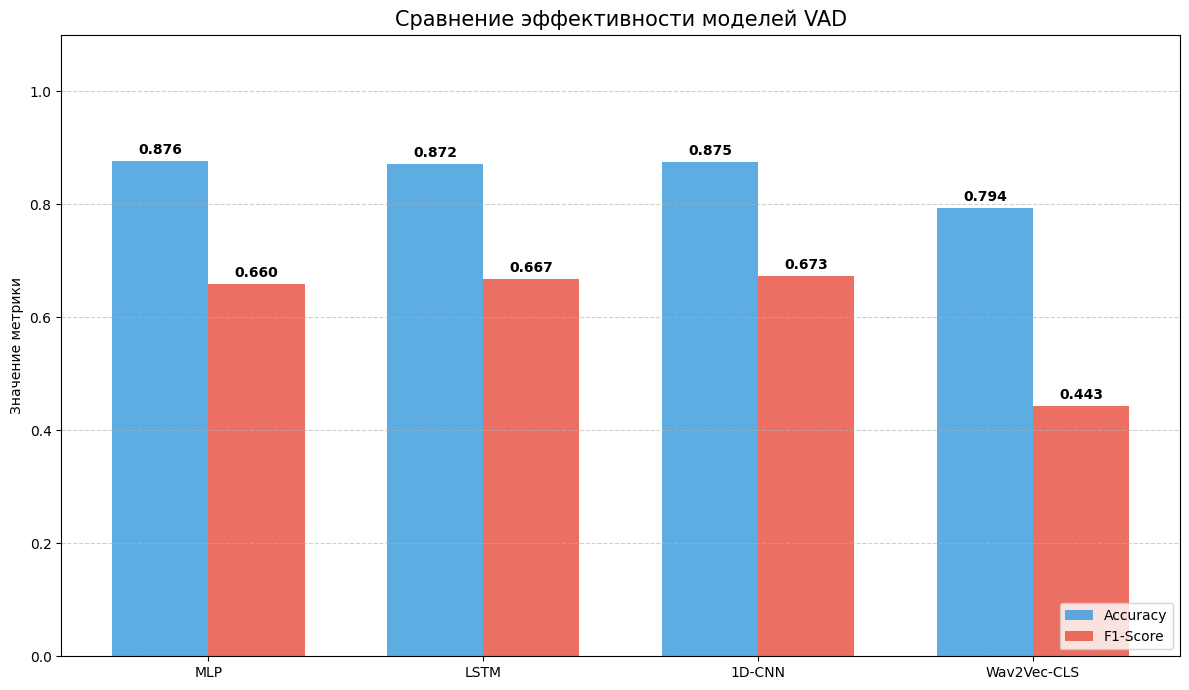

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_vad_comparison(df):
    plt.figure(figsize=(12, 7))
    
    # Настройки расположения столбцов
    x = np.arange(len(df['Model']))
    width = 0.35  # Ширина столбцов
    
    # Рисуем столбцы для Accuracy и F1-Score
    rects1 = plt.bar(x - width/2, df['Accuracy'], width, label='Accuracy', color='#3498db', alpha=0.8)
    rects2 = plt.bar(x + width/2, df['F1-Score'], width, label='F1-Score', color='#e74c3c', alpha=0.8)
    
    # Добавляем текст, сетку и подписи
    plt.ylabel('Значение метрики')
    plt.title('Сравнение эффективности моделей VAD', fontsize=15)
    plt.xticks(x, df['Model'])
    plt.ylim(0, 1.1) # Ограничиваем от 0 до 1.1 для наглядности меток
    plt.legend(loc='lower right')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Функция для добавления подписей значений над столбцами
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            plt.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)
    
    plt.tight_layout()
    plt.show()

# Визуализируем
plot_vad_comparison(df_results)